In [1]:
import pandas as pd
import yfinance as yf
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [3]:
df = pd.read_csv("sp500_data.csv")

In [5]:
df["entry_open_price"].isna().sum()

285

In [7]:
df.describe()

,year,entry_open_price,close_plus_20,return_1m,close_plus_60,return_3m,sp500_open,sp500_close_plus_20,sp500_return_1m,sp500_close_plus_60,...,close_minus_5,return_vs_minus_5,close_minus_20,return_vs_minus_20,sp500_close_minus_20,sp500_return_vs_minus_20,close_minus_60,return_vs_minus_60,sp500_close_minus_60,sp500_return_vs_minus_60
count,753.000000,468.000000,466.000000,466.000000,462.000000,462.000000,753.000000,753.000000,753.000000,749.000000,...,455.000000,455.000000,428.000000,428.000000,751.000000,751.000000,427.000000,427.000000,746.000000,746.000000
mean,2009.393094,95.573117,96.090750,-0.001365,91.964210,0.009338,1974.037184,1994.647130,0.009651,1989.033698,...,96.007979,0.022086,97.043927,0.047700,1975.010454,0.000580,89.474501,0.114123,1966.376224,0.007417
std,8.650548,217.036710,222.880449,0.110930,215.363487,0.198983,1296.354661,1321.529877,0.050168,1314.673041,...,222.189841,0.075873,218.066723,0.139969,1282.751305,0.046852,197.623833,0.272894,1251.864732,0.086343
min,1996.000000,0.300000,0.430000,-0.470478,0.190000,-0.738398,637.090027,631.179993,-0.245636,643.559998,...,0.180000,-0.225545,0.150000,-0.490884,638.729980,-0.197492,0.250000,-0.695316,626.869995,-0.375443
25%,2001.000000,18.076041,17.375468,-0.060771,16.347341,-0.098762,1160.329956,1162.099976,-0.014658,1164.079956,...,17.317939,-0.020796,17.623417,-0.021501,1175.309998,-0.022428,16.863146,-0.013344,1175.305023,-0.030963
50%,2008.000000,38.604021,38.292097,0.005034,37.306084,0.015018,1402.109985,1413.040039,0.012614,1409.459961,...,37.839035,0.012844,39.223423,0.033401,1403.880005,0.008054,37.955002,0.085771,1404.769958,0.023130
75%,2017.000000,100.927614,96.743195,0.054175,92.575617,0.116241,2394.750000,2389.520020,0.037009,2419.699951,...,103.290039,0.056258,106.660469,0.095940,2375.059937,0.028931,98.673519,0.193438,2345.959961,0.058341
max,2025.000000,3591.550049,3759.510010,0.433333,3840.739990,1.018177,6879.169922,6913.350098,0.168099,6969.009766,...,3698.689941,0.666667,3591.889893,1.000000,6715.790039,0.193363,3367.750000,3.029405,6643.700195,0.310954


In [9]:
df_filtered = df.dropna(subset=["entry_open_price"]).copy()

In [11]:
df_filtered.describe()

,year,entry_open_price,close_plus_20,return_1m,close_plus_60,return_3m,sp500_open,sp500_close_plus_20,sp500_return_1m,sp500_close_plus_60,...,close_minus_5,return_vs_minus_5,close_minus_20,return_vs_minus_20,sp500_close_minus_20,sp500_return_vs_minus_20,close_minus_60,return_vs_minus_60,sp500_close_minus_60,sp500_return_vs_minus_60
count,468.000000,468.000000,466.000000,466.000000,462.000000,462.000000,468.000000,468.000000,468.000000,464.000000,...,455.000000,455.000000,428.000000,428.000000,467.000000,467.000000,427.000000,427.000000,466.000000,466.000000
mean,2012.196581,95.573117,96.090750,-0.001365,91.964210,0.009338,2315.365875,2343.320254,0.010309,2334.028447,...,96.007979,0.022086,97.043927,0.047700,2314.249103,0.001455,89.474501,0.114123,2293.405027,0.010216
std,8.496115,217.036710,222.880449,0.110930,215.363487,0.198983,1460.012427,1490.556943,0.051051,1481.713447,...,222.189841,0.075873,218.066723,0.139969,1444.453619,0.047092,197.623833,0.272894,1412.629020,0.083153
min,1996.000000,0.300000,0.430000,-0.470478,0.190000,-0.738398,643.510010,644.239990,-0.197910,643.559998,...,0.180000,-0.225545,0.150000,-0.490884,650.039978,-0.197492,0.250000,-0.695316,650.169983,-0.323942
25%,2006.000000,18.076041,17.375468,-0.060771,16.347341,-0.098762,1239.832458,1254.152466,-0.014488,1233.420044,...,17.317939,-0.020796,17.623417,-0.021501,1234.940002,-0.015182,16.863146,-0.013344,1249.865051,-0.025908
50%,2014.000000,38.604021,38.292097,0.005034,37.306084,0.015018,1880.890015,1882.410034,0.014297,1862.984985,...,37.839035,0.012844,39.223423,0.033401,1873.810059,0.009307,37.955002,0.085771,1790.929993,0.027825
75%,2019.000000,100.927614,96.743195,0.054175,92.575617,0.116241,2984.057495,3057.267517,0.036192,3039.024963,...,103.290039,0.056258,106.660469,0.095940,2972.370117,0.030393,98.673519,0.193438,2970.205017,0.058457
max,2025.000000,3591.550049,3759.510010,0.433333,3840.739990,1.018177,6879.169922,6913.350098,0.161008,6969.009766,...,3698.689941,0.666667,3591.889893,1.000000,6715.790039,0.178778,3367.750000,3.029405,6643.700195,0.310954


In [13]:
summary_1m = (
    df_filtered
    .groupby("year")["up_1m"]
    .agg(
        total="count",
        up="sum"
    )
)

summary_1m["down"] = summary_1m["total"] - summary_1m["up"]
summary_1m["hit_ratio"] = summary_1m["up"] / summary_1m["total"]

In [15]:
summary_1m

,total,up,down,hit_ratio
year,,,,
1996,4,2,2,0.500000
1997,19,7,12,0.368421
1998,14,4,10,0.285714
1999,16,10,6,0.625000
2000,15,7,8,0.466667
2001,9,6,3,0.666667
2002,11,7,4,0.636364
2003,6,3,3,0.500000
2004,5,3,2,0.600000


In [17]:
summary_1m.describe()

,total,up,down,hit_ratio
count,30.000000,30.000000,30.000000,30.000000
mean,15.600000,8.166667,7.433333,0.522575
std,5.863975,4.043584,3.460948,0.129409
min,4.000000,2.000000,2.000000,0.263158
25%,12.000000,5.250000,4.000000,0.452885
50%,16.000000,8.000000,7.000000,0.500000
75%,19.750000,10.000000,10.000000,0.611538
max,27.000000,21.000000,14.000000,0.840000


In [19]:
summary_3m = (
    df_filtered
    .groupby("year")["up_3m"]
    .agg(
        total="count",
        up="sum"
    )
)

summary_3m["down"] = summary_3m["total"] - summary_3m["up"]
summary_3m["hit_ratio"] = summary_3m["up"] / summary_3m["total"]

In [21]:
summary_3m

,total,up,down,hit_ratio
year,,,,
1996,4,1,3,0.250000
1997,19,8,11,0.421053
1998,14,6,8,0.428571
1999,16,9,7,0.562500
2000,15,9,6,0.600000
2001,9,3,6,0.333333
2002,11,3,8,0.272727
2003,6,6,0,1.000000
2004,5,4,1,0.800000


In [23]:
summary_3m.describe()

,total,up,down,hit_ratio
count,30.000000,30.000000,30.000000,30.000000
mean,15.600000,8.333333,7.266667,0.531489
std,5.863975,4.357580,3.590537,0.184522
min,4.000000,1.000000,0.000000,0.210526
25%,12.000000,6.000000,5.000000,0.402273
50%,16.000000,8.000000,6.500000,0.533937
75%,19.750000,9.000000,9.000000,0.659091
max,27.000000,20.000000,15.000000,1.000000


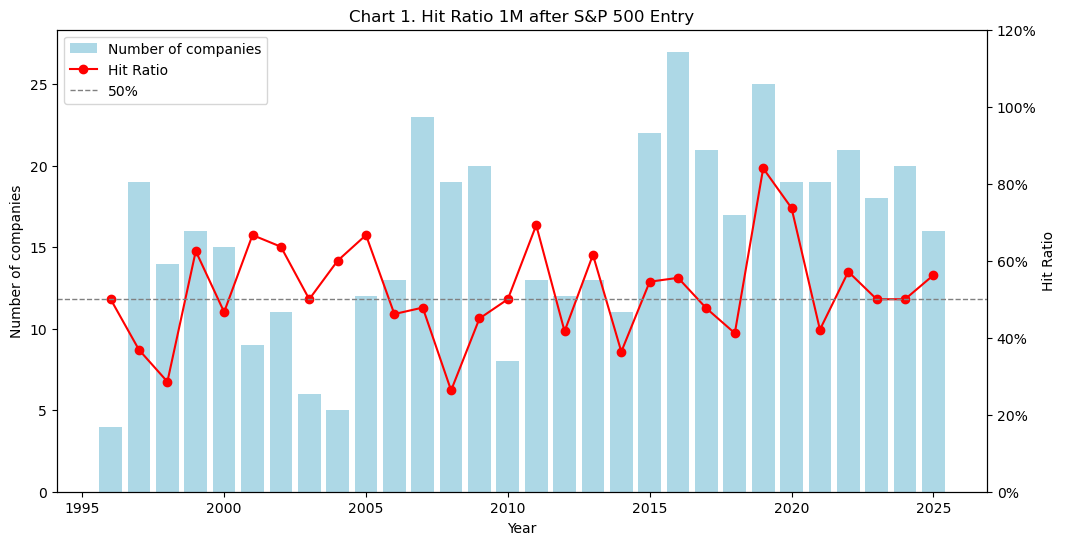

In [25]:
df_clean = df_filtered.dropna(subset=['up_1m']).copy()

summary_1m = (
    df_clean
    .groupby("year")["up_1m"]
    .agg(
        total='count',
        up='sum'
    )
)
summary_1m["hit_ratio"] = summary_1m["up"] / summary_1m["total"]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    summary_1m.index,
    summary_1m["total"],
    color='lightblue',
    label='Number of companies'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of companies")
ax1.set_title("Chart 1. Hit Ratio 1M after S&P 500 Entry")

ax2 = ax1.twinx()
ax2.plot(
    summary_1m.index,
    summary_1m["hit_ratio"],
    color='red',
    marker='o',
    label='Hit Ratio'
)

ax2.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

ax2.set_ylabel("Hit Ratio")
ax2.set_ylim(0, 1.2)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# Legenda w prawym górnym rogu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

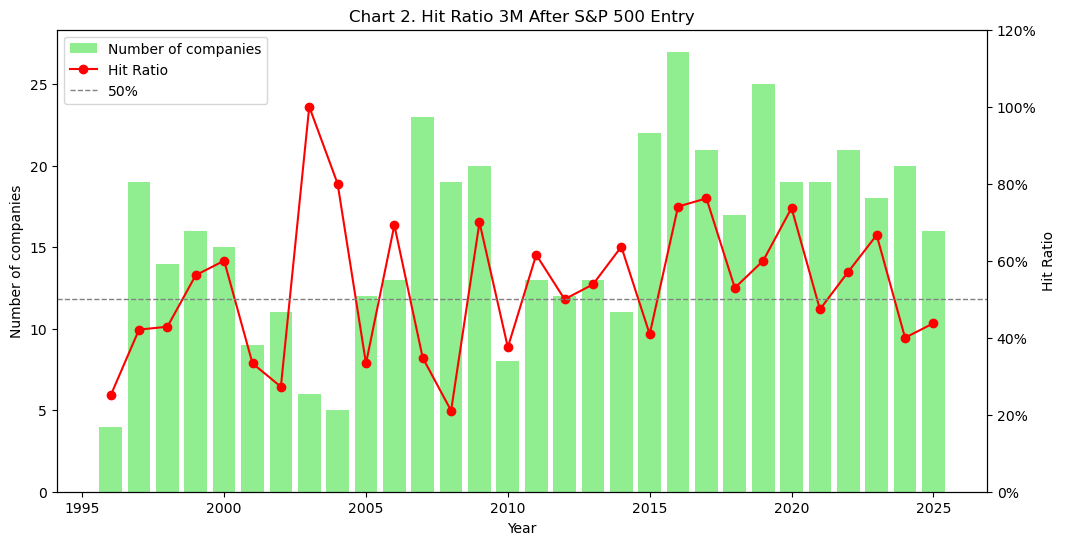

In [27]:
df_clean = df_filtered.dropna(subset=['up_3m']).copy()

summary_3m = (
    df_clean
    .groupby("year")["up_3m"]
    .agg(
        total='count',
        up='sum'
    )
)
summary_3m["hit_ratio"] = summary_3m["up"] / summary_3m["total"]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    summary_3m.index,
    summary_3m["total"],
    color='lightgreen',
    label='Number of companies'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of companies")
ax1.set_title("Chart 2. Hit Ratio 3M After S&P 500 Entry")

ax2 = ax1.twinx()
ax2.plot(
    summary_3m.index,
    summary_3m["hit_ratio"],
    color='red',
    marker='o',
    label='Hit Ratio'
)

ax2.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

ax2.set_ylabel("Hit Ratio")
ax2.set_ylim(0, 1.2)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

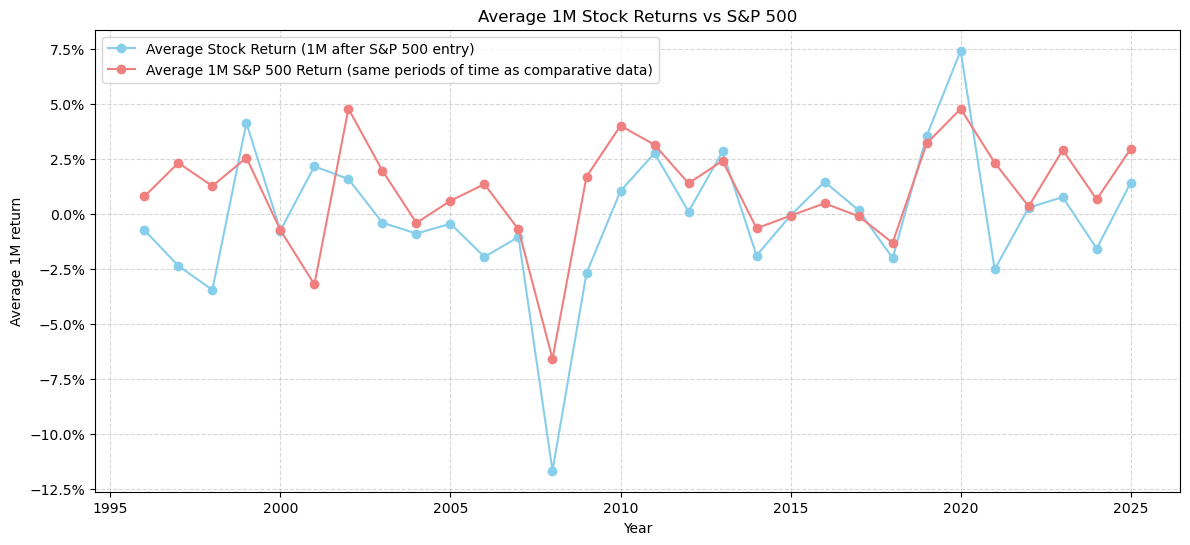

In [29]:
summary_1m_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return_1m=("return_1m", "mean"),
        avg_sp500_return_1m=("sp500_return_1m", "mean")
    )
).reset_index()

plt.figure(figsize=(14,6))
plt.plot(
    summary_1m_returns["year"], 
    summary_1m_returns["avg_stock_return_1m"], 
    marker='o', label='Average Stock Return (1M after S&P 500 entry)', color='skyblue'
)
plt.plot(
    summary_1m_returns["year"], 
    summary_1m_returns["avg_sp500_return_1m"], 
    marker='o', label='Average 1M S&P 500 Return (same periods of time as comparative data)', color='lightcoral'
)

plt.xlabel("Year")
plt.ylabel("Average 1M return")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title("Average 1M Stock Returns vs S&P 500")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [31]:
summary_1m_returns

,year,avg_stock_return_1m,avg_sp500_return_1m
0,1996,-0.007311,0.007968
1,1997,-0.023573,0.023211
2,1998,-0.034495,0.012714
3,1999,0.041370,0.025570
4,2000,-0.007544,-0.007328
5,2001,0.021639,-0.032010
6,2002,0.015868,0.047815
7,2003,-0.003953,0.019655
8,2004,-0.008915,-0.004055
9,2005,-0.004416,0.006003


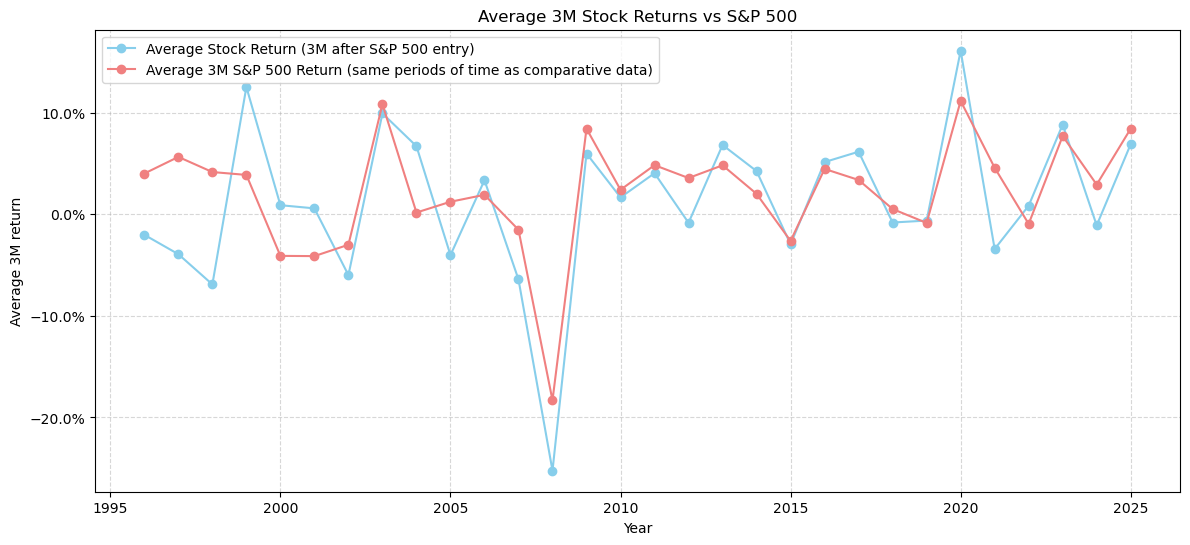

In [33]:
summary_3m_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return_3m=("return_3m", "mean"),
        avg_sp500_return_3m=("sp500_return_3m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(
    summary_3m_returns["year"], 
    summary_3m_returns["avg_stock_return_3m"], 
    marker='o', label='Average Stock Return (3M after S&P 500 entry)', color='skyblue'
)
plt.plot(
    summary_3m_returns["year"], 
    summary_3m_returns["avg_sp500_return_3m"], 
    marker='o', label='Average 3M S&P 500 Return (same periods of time as comparative data)', color='lightcoral'
)

plt.xlabel("Year")
plt.ylabel("Average 3M return")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title("Average 3M Stock Returns vs S&P 500")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [35]:
summary_3m_returns

,year,avg_stock_return_3m,avg_sp500_return_3m
0,1996,-0.020132,0.040204
1,1997,-0.039212,0.056569
2,1998,-0.068958,0.041665
3,1999,0.125374,0.038840
4,2000,0.009015,-0.040875
5,2001,0.005906,-0.041108
6,2002,-0.059793,-0.029922
7,2003,0.099383,0.108453
8,2004,0.067126,0.001797
9,2005,-0.040119,0.012420


In [37]:
bear_periods = [
    ("2000-03-01", "2002-10-09"),
    ("2007-10-01", "2009-03-09"),
    ("2020-02-19", "2020-03-23"),
    ("2022-01-01", "2022-10-12")
]

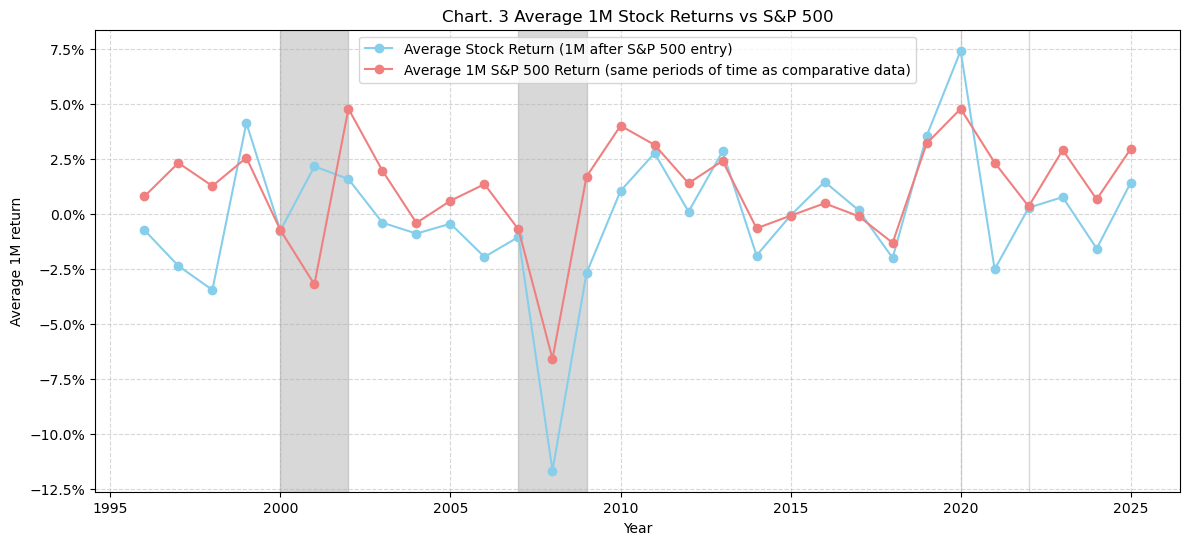

In [39]:
summary_1m_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return_1m=("return_1m", "mean"),
        avg_sp500_return_1m=("sp500_return_1m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    summary_1m_returns["year"], 
    summary_1m_returns["avg_stock_return_1m"], 
    marker='o', label='Average Stock Return (1M after S&P 500 entry)', color='skyblue'
)
plt.plot(
    summary_1m_returns["year"], 
    summary_1m_returns["avg_sp500_return_1m"], 
    marker='o', label='Average 1M S&P 500 Return (same periods of time as comparative data)', color='lightcoral'
)

for start, end in bear_periods:
    start_year = pd.to_datetime(start).year
    end_year = pd.to_datetime(end).year
    plt.axvspan(start_year, end_year, color='grey', alpha=0.3)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xlabel("Year")
plt.ylabel("Average 1M return")
plt.title("Chart. 3 Average 1M Stock Returns vs S&P 500")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

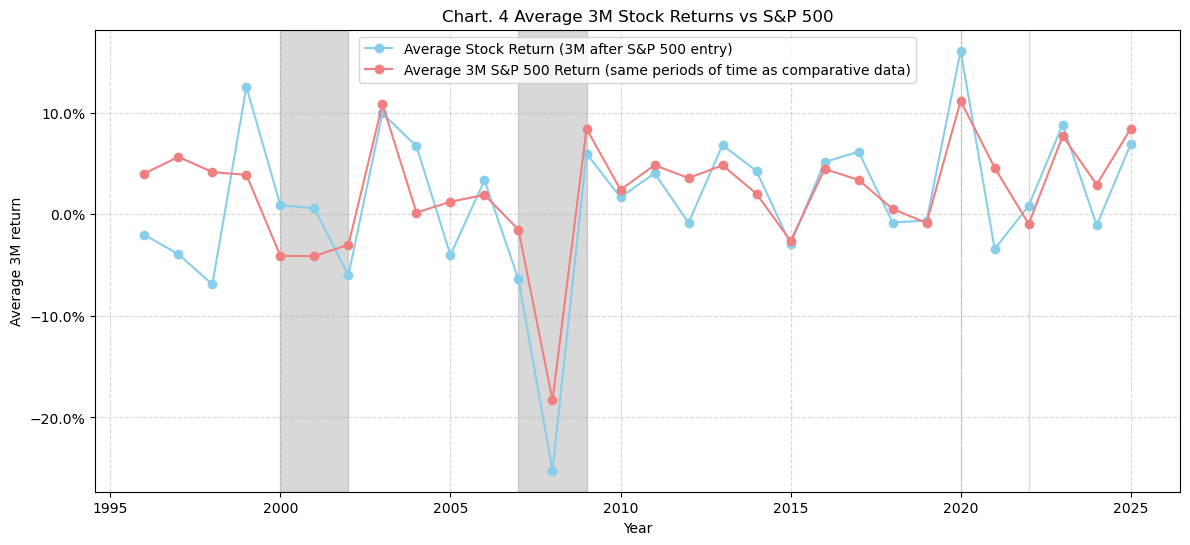

In [41]:
summary_3m_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return_3m=("return_3m", "mean"),
        avg_sp500_return_3m=("sp500_return_3m", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    summary_3m_returns["year"], 
    summary_3m_returns["avg_stock_return_3m"], 
    marker='o', label='Average Stock Return (3M after S&P 500 entry)', color='skyblue'
)
plt.plot(
    summary_3m_returns["year"], 
    summary_3m_returns["avg_sp500_return_3m"], 
    marker='o', label='Average 3M S&P 500 Return (same periods of time as comparative data)', color='lightcoral'
)

for start, end in bear_periods:
    start_year = pd.to_datetime(start).year
    end_year = pd.to_datetime(end).year
    plt.axvspan(start_year, end_year, color='grey', alpha=0.3)


plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))


plt.xlabel("Year")
plt.ylabel("Average 3M return")
plt.title("Chart. 4 Average 3M Stock Returns vs S&P 500")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [43]:
sp500 = yf.download("^GSPC", start="1995-01-01", end="2026-01-01", progress=False, auto_adjust=True)

sp500 = sp500.reset_index()

sp500['year'] = sp500['Date'].dt.year

annual_close = sp500.groupby('year')['Close'].last().sort_index()
sp500_annual_return = annual_close.pct_change().dropna().reset_index()
sp500_annual_return.columns = ['year', 'sp500_annual_return']

sp500_annual_return

,year,sp500_annual_return
0,1996,0.202637
1,1997,0.310082
2,1998,0.266686
3,1999,0.195260
4,2000,-0.101392
5,2001,-0.130427
6,2002,-0.233660
7,2003,0.263804
8,2004,0.089935
9,2005,0.030010


In [45]:
summary_1m = summary_1m.reset_index()
summary_1m = summary_1m.merge(sp500_annual_return, on="year", how="left")

In [47]:
summary_1m

,year,total,up,hit_ratio,sp500_annual_return
0,1996,4,2,0.500000,0.202637
1,1997,19,7,0.368421,0.310082
2,1998,14,4,0.285714,0.266686
3,1999,16,10,0.625000,0.195260
4,2000,15,7,0.466667,-0.101392
5,2001,9,6,0.666667,-0.130427
6,2002,11,7,0.636364,-0.233660
7,2003,6,3,0.500000,0.263804
8,2004,5,3,0.600000,0.089935
9,2005,12,8,0.666667,0.030010


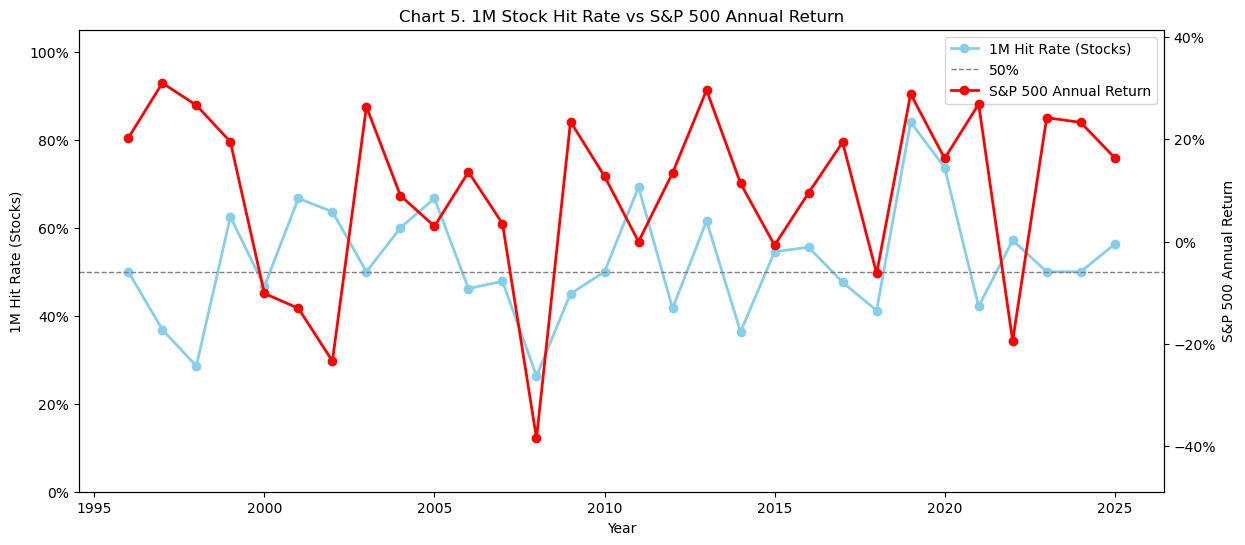

In [49]:
fig, ax1 = plt.subplots(figsize=(14,6))

line_hit, = ax1.plot(
    summary_1m['year'], 
    summary_1m['hit_ratio'], 
    color='skyblue',
    marker='o',
    linewidth=2,
    label='1M Hit Rate (Stocks)'
)

line50 = ax1.axhline(
    0.5, color='grey', linestyle='--', linewidth=1, label='50%'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("1M Hit Rate (Stocks)")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0)) 

ax2 = ax1.twinx()

line_sp500, = ax2.plot(
    summary_1m['year'], 
    summary_1m['sp500_annual_return'], 
    color='red', 
    marker='o',
    linewidth=2,
    label='S&P 500 Annual Return'
)

min_sp = summary_1m['sp500_annual_return'].min()
max_sp = summary_1m['sp500_annual_return'].max()
margin = (max_sp - min_sp) * 0.15
ax2.set_ylim(min_sp - margin, max_sp + margin)

ax2.set_ylabel("S&P 500 Annual Return")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.grid(False)

lines = [line_hit, line50, line_sp500]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Chart 5. 1M Stock Hit Rate vs S&P 500 Annual Return")
plt.show()

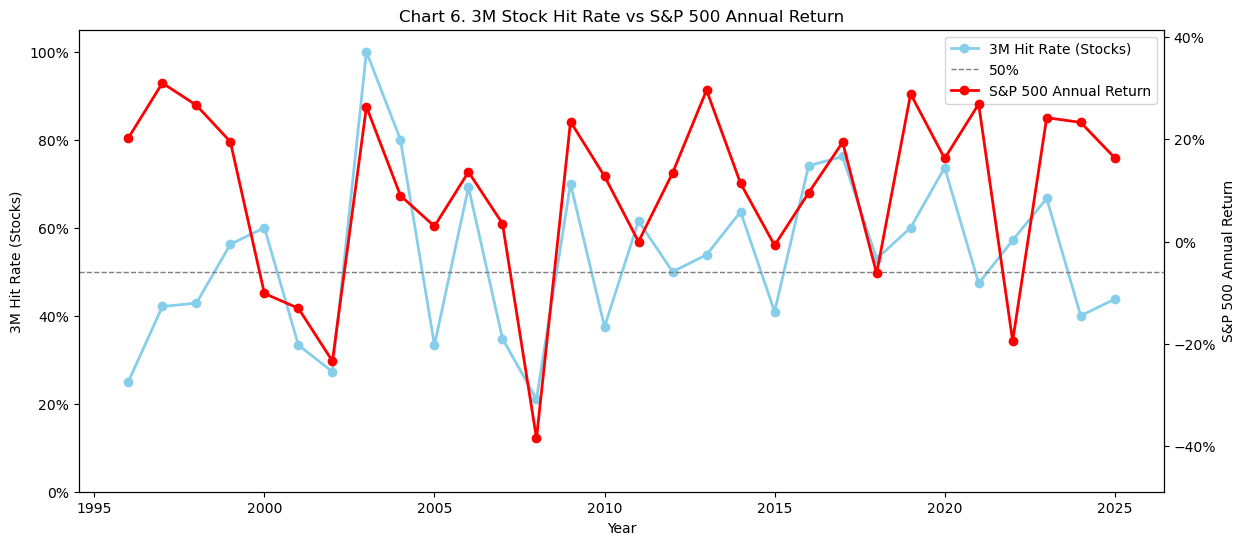

In [51]:
hit_rate_3m = df_filtered.groupby('year')['up_3m'].mean().reset_index()
hit_rate_3m.columns = ['year', 'hit_rate_3m']

summary_3m = pd.merge(hit_rate_3m, sp500_annual_return, on='year', how='inner')

fig, ax1 = plt.subplots(figsize=(14,6))

line_hit, = ax1.plot(
    summary_3m['year'],
    summary_3m['hit_rate_3m'],
    color='skyblue',
    marker='o',
    linewidth=2,
    label='3M Hit Rate (Stocks)'
)

line50 = ax1.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("3M Hit Rate (Stocks)")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))

ax2 = ax1.twinx()

line_sp500, = ax2.plot(
    summary_3m['year'],
    summary_3m['sp500_annual_return'],
    color='red',
    marker='o',
    linewidth=2,
    label='S&P 500 Annual Return'
)

min_sp = summary_3m['sp500_annual_return'].min()
max_sp = summary_3m['sp500_annual_return'].max()
margin = (max_sp - min_sp) * 0.15
ax2.set_ylim(min_sp - margin, max_sp + margin)

ax2.set_ylabel("S&P 500 Annual Return")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.grid(False)

lines = [line_hit, line50, line_sp500]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Chart 6. 3M Stock Hit Rate vs S&P 500 Annual Return")
plt.show()

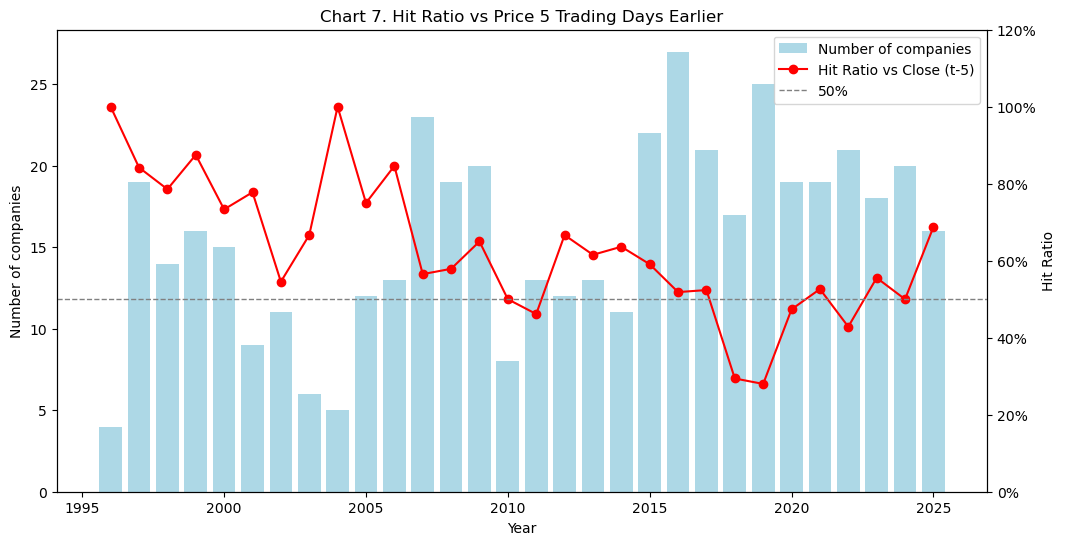

In [53]:
df_clean = df_filtered.dropna(subset=['up_vs_minus_5']).copy()

summary_minus_5 = (
    df_clean
    .groupby("year")["up_vs_minus_5"]
    .agg(
        total='count',
        up='sum'
    )
)
summary_minus_5["hit_ratio"] = summary_minus_5["up"] / summary_minus_5["total"]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    summary_minus_5.index,
    summary_minus_5["total"],
    color='lightblue',
    label='Number of companies'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of companies")
ax1.set_title("Chart 7. Hit Ratio vs Price 5 Trading Days Earlier")

ax2 = ax1.twinx()
ax2.plot(
    summary_minus_5.index,
    summary_minus_5["hit_ratio"],
    color='red',
    marker='o',
    label='Hit Ratio vs Close (t-5)'
)

ax2.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

ax2.set_ylabel("Hit Ratio")
ax2.set_ylim(0, 1.2)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

In [55]:
summary_minus_5

,total,up,hit_ratio
year,,,
1996,4,4,1.000000
1997,19,16,0.842105
1998,14,11,0.785714
1999,16,14,0.875000
2000,15,11,0.733333
2001,9,7,0.777778
2002,11,6,0.545455
2003,6,4,0.666667
2004,5,5,1.000000


In [57]:
summary_minus_5

,total,up,hit_ratio
year,,,
1996,4,4,1.000000
1997,19,16,0.842105
1998,14,11,0.785714
1999,16,14,0.875000
2000,15,11,0.733333
2001,9,7,0.777778
2002,11,6,0.545455
2003,6,4,0.666667
2004,5,5,1.000000


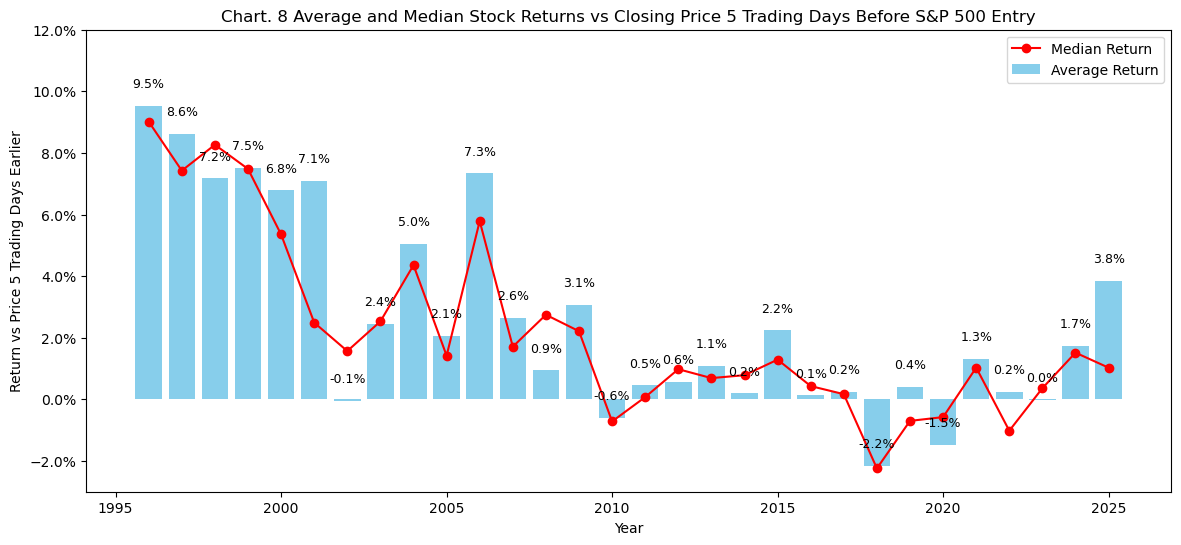

In [59]:
summary_minus_5 = (
    df_filtered
    .groupby('year')['return_vs_minus_5']
    .agg(mean_return='mean', median_return='median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.bar(
    summary_minus_5['year'], 
    summary_minus_5['mean_return'], 
    color='skyblue', 
    label='Average Return'
)

ax.plot(
    summary_minus_5['year'], 
    summary_minus_5['median_return'], 
    color='red', 
    marker='o', 
    label='Median Return'
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(bottom=-0.03, top=0.12)

ax.set_xlabel("Year")
ax.set_ylabel("Return vs Price 5 Trading Days Earlier")
ax.set_title(
    "Chart. 8 Average and Median Stock Returns vs Closing Price 5 Trading Days "
    "Before S&P 500 Entry"
)

for bar in bars:
    height = bar.get_height()
    display_height = 0.0 if abs(height) < 0.0005 else height
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{display_height*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.legend(loc='upper right')

plt.show()

In [61]:
summary_minus_5

,year,mean_return,median_return
0,1996,0.095289,0.090151
1,1997,0.086254,0.074246
2,1998,0.071699,0.082644
3,1999,0.075121,0.074797
4,2000,0.067800,0.053519
5,2001,0.071001,0.024911
6,2002,-0.000533,0.015669
7,2003,0.024483,0.025299
8,2004,0.050467,0.043565
9,2005,0.020688,0.014176


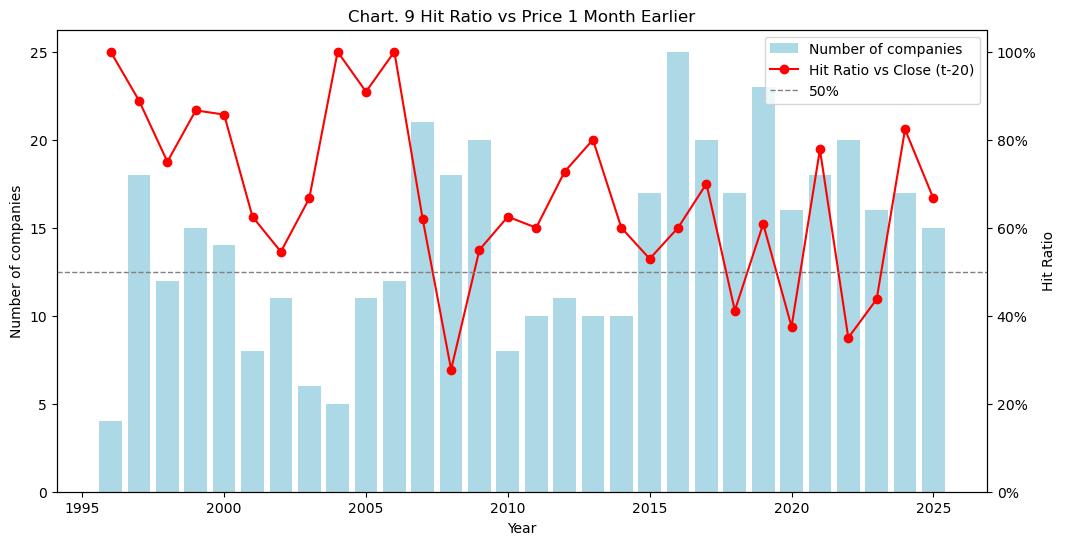

In [63]:
df_clean = df_filtered.dropna(subset=['entry_open_price', 'close_minus_20']).copy()

df_clean['up_vs_minus_20'] = df_clean['entry_open_price'] > df_clean['close_minus_20']

summary_minus_20 = (
    df_clean
    .groupby("year")["up_vs_minus_20"]
    .agg(
        total='count',
        up='sum'
    )
)

summary_minus_20["hit_ratio"] = summary_minus_20["up"] / summary_minus_20["total"]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    summary_minus_20.index,
    summary_minus_20["total"],
    color='lightblue',
    label='Number of companies'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of companies")
ax1.set_title("Chart. 9 Hit Ratio vs Price 1 Month Earlier")

ax2 = ax1.twinx()
ax2.plot(
    summary_minus_20.index,
    summary_minus_20["hit_ratio"],
    color='red',
    marker='o',
    label='Hit Ratio vs Close (t-20)'
)

ax2.set_ylabel("Hit Ratio")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

ax2.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

In [65]:
summary_minus_20

,total,up,hit_ratio
year,,,
1996,4,4,1.000000
1997,18,16,0.888889
1998,12,9,0.750000
1999,15,13,0.866667
2000,14,12,0.857143
2001,8,5,0.625000
2002,11,6,0.545455
2003,6,4,0.666667
2004,5,5,1.000000


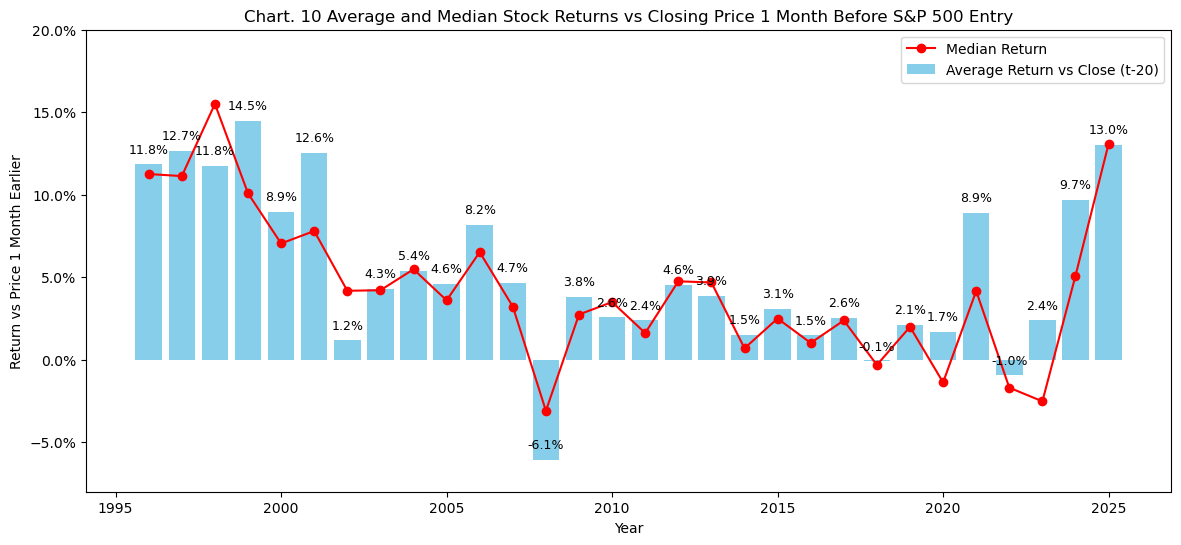

In [67]:
summary_minus_20 = (
    df_filtered
    .groupby('year')['return_vs_minus_20']
    .agg(mean_return='mean', median_return='median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14,6))

bars = ax.bar(
    summary_minus_20['year'], 
    summary_minus_20['mean_return'], 
    color='skyblue', 
    label='Average Return vs Close (t-20)'
)

ax.plot(
    summary_minus_20['year'], 
    summary_minus_20['median_return'], 
    color='red', 
    marker='o', 
    label='Median Return'
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(bottom=-0.08, top=0.20)
ax.set_xlabel("Year")
ax.set_ylabel("Return vs Price 1 Month Earlier")
ax.set_title(
    "Chart. 10 Average and Median Stock Returns vs Closing Price 1 Month "
    "Before S&P 500 Entry"
)

for bar in bars:
    height = bar.get_height()
    display_height = 0.0 if abs(height) < 0.0005 else height
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{display_height*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.legend(loc='upper right')

plt.show()

In [69]:
summary_minus_20

,year,mean_return,median_return
0,1996,0.118390,0.112543
1,1997,0.126766,0.111285
2,1998,0.117666,0.155042
3,1999,0.144698,0.100840
4,2000,0.089466,0.070456
5,2001,0.125545,0.078001
6,2002,0.011726,0.041792
7,2003,0.042819,0.042094
8,2004,0.053999,0.054813
9,2005,0.045819,0.036005


In [71]:
summary_minus_20.describe()

,year,mean_return,median_return
count,30.000000,30.000000,30.000000
mean,2010.500000,0.052363,0.043078
std,8.803408,0.049102,0.045370
min,1996.000000,-0.060645,-0.030950
25%,2003.250000,0.021721,0.017113
50%,2010.500000,0.040746,0.038829
75%,2017.750000,0.089345,0.062607
max,2025.000000,0.144698,0.155042


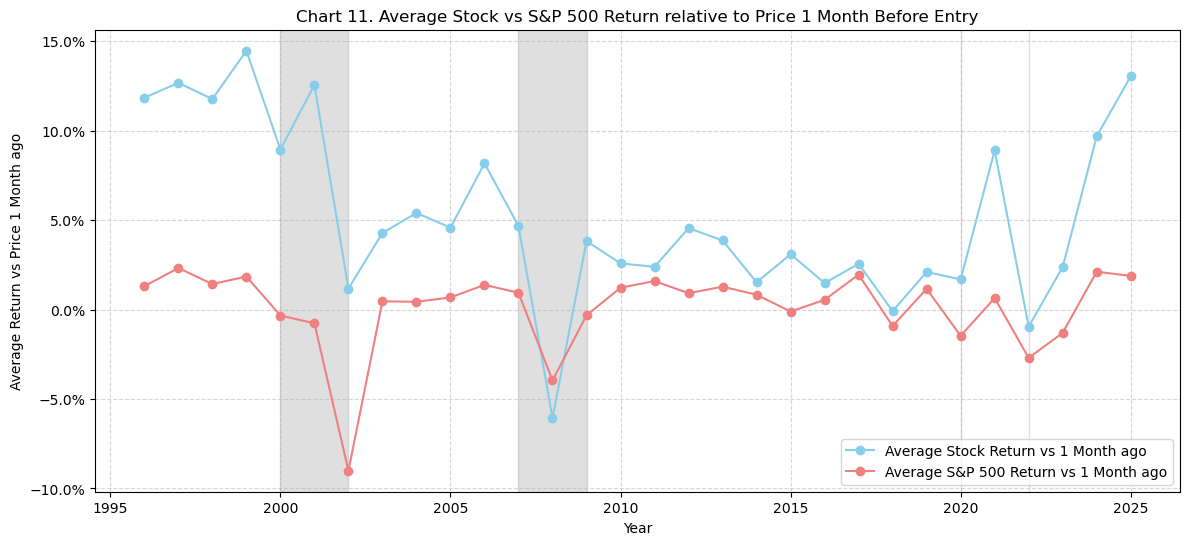

In [73]:
summary_minus_20_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return=("return_vs_minus_20", "mean"),
        avg_sp500_return=("sp500_return_vs_minus_20", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    summary_minus_20_returns["year"], 
    summary_minus_20_returns["avg_stock_return"], 
    marker='o', 
    label='Average Stock Return vs 1 Month ago', 
    color='skyblue'
)

plt.plot(
    summary_minus_20_returns["year"], 
    summary_minus_20_returns["avg_sp500_return"], 
    marker='o', 
    label='Average S&P 500 Return vs 1 Month ago', 
    color='lightcoral'
)

for i, (start, end) in enumerate(bear_periods):
    start_year = pd.to_datetime(start).year
    end_year = pd.to_datetime(end).year
    
    plt.axvspan(
        start_year, 
        end_year, 
        color='grey', 
        alpha=0.25,
    )

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xlabel("Year")
plt.ylabel("Average Return vs Price 1 Month ago")
plt.title("Chart 11. Average Stock vs S&P 500 Return relative to Price 1 Month Before Entry")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [75]:
summary_minus_20_returns

,year,avg_stock_return,avg_sp500_return
0,1996,0.118390,0.013041
1,1997,0.126766,0.023220
2,1998,0.117666,0.014245
3,1999,0.144698,0.018459
4,2000,0.089466,-0.003328
5,2001,0.125545,-0.007686
6,2002,0.011726,-0.090094
7,2003,0.042819,0.004602
8,2004,0.053999,0.004350
9,2005,0.045819,0.006779


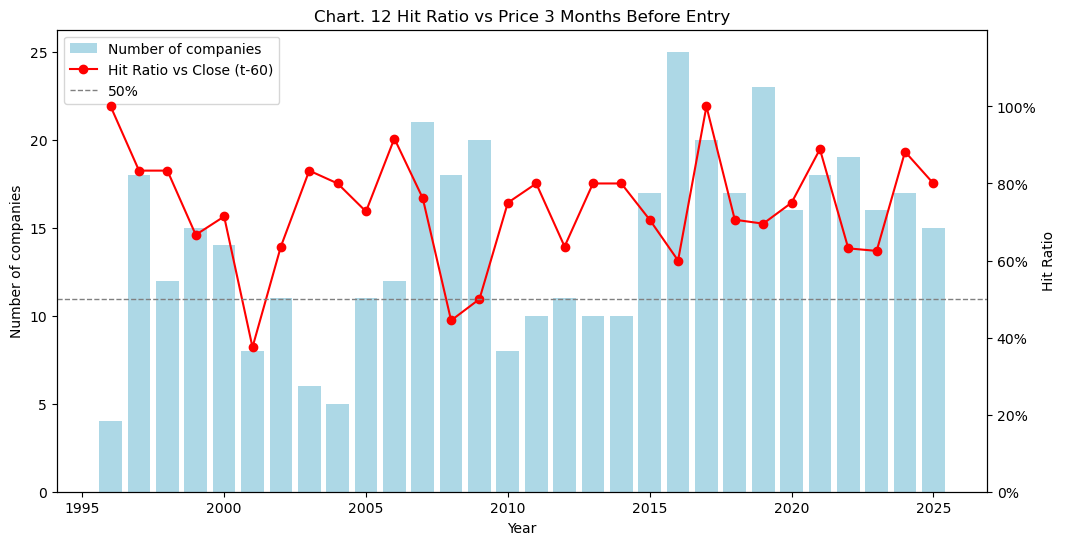

In [77]:
df_clean = df_filtered.dropna(subset=['entry_open_price', 'close_minus_60']).copy()

df_clean['up_vs_minus_60'] = df_clean['entry_open_price'] > df_clean['close_minus_60']

summary_minus_60 = (
    df_clean
    .groupby("year")["up_vs_minus_60"]
    .agg(
        total='count',
        up='sum'
    )
)
summary_minus_60["hit_ratio"] = summary_minus_60["up"] / summary_minus_60["total"]

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    summary_minus_60.index,
    summary_minus_60["total"],
    color='lightblue',
    label='Number of companies'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of companies")
ax1.set_title("Chart. 12 Hit Ratio vs Price 3 Months Before Entry")

ax2 = ax1.twinx()
ax2.plot(
    summary_minus_60.index,
    summary_minus_60["hit_ratio"],
    color='red',
    marker='o',
    label='Hit Ratio vs Close (t-60)'
)

ax2.set_ylim(0, 1.199)
ax2.set_ylabel("Hit Ratio")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

ax2.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=1,
    label='50%'
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

In [79]:
summary_minus_60 = (
    df_filtered
    .groupby("year")["return_vs_minus_60"]
    .agg(mean_return="mean", median_return="median")
    .reset_index()
)

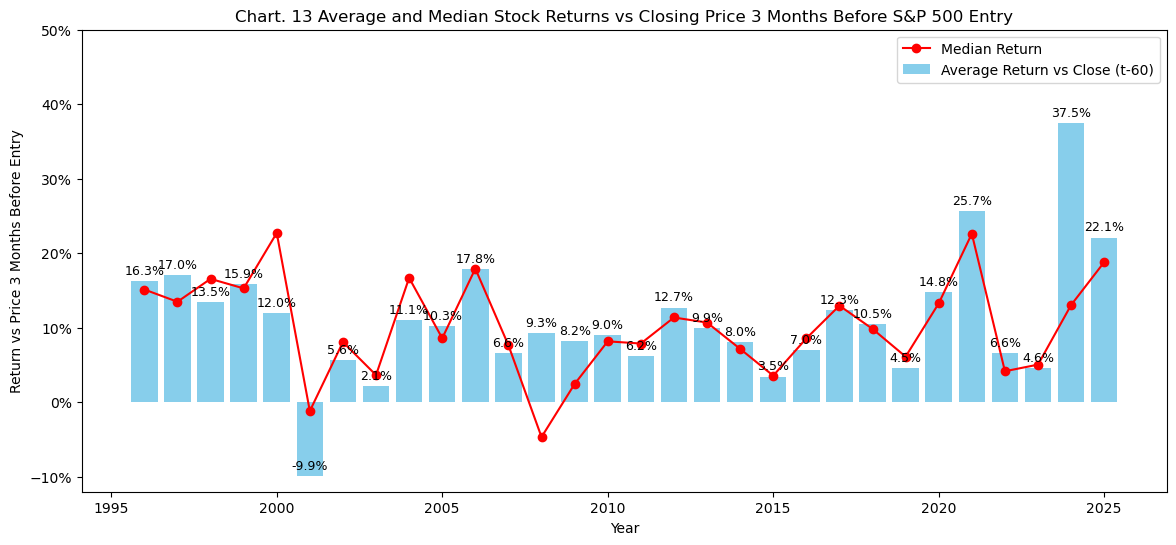

In [81]:
fig, ax = plt.subplots(figsize=(14,6))

bars = ax.bar(
    summary_minus_60['year'], 
    summary_minus_60['mean_return'], 
    color='skyblue', 
    label='Average Return vs Close (t-60)'
)

ax.plot(
    summary_minus_60['year'], 
    summary_minus_60['median_return'], 
    color='red', 
    marker='o', 
    label='Median Return'
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(bottom=-0.12, top=0.50)

ax.set_xlabel("Year")
ax.set_ylabel("Return vs Price 3 Months Before Entry")
ax.set_title(
    "Chart. 13 Average and Median Stock Returns vs Closing Price 3 Months Before S&P 500 Entry"
)

for bar in bars:
    height = bar.get_height()
    display_height = 0.0 if abs(height) < 0.0005 else height
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{display_height*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.legend(loc='upper right')

plt.show()

In [83]:
summary_minus_60

,year,mean_return,median_return
0,1996,0.163146,0.151378
1,1997,0.170327,0.134920
2,1998,0.134700,0.165644
3,1999,0.158641,0.152875
4,2000,0.120098,0.227218
5,2001,-0.099342,-0.011705
6,2002,0.056107,0.080893
7,2003,0.021217,0.036501
8,2004,0.110577,0.166986
9,2005,0.102620,0.085952


In [85]:
summary_minus_60_returns = (
    df_filtered
    .groupby("year")
    .agg(
        avg_stock_return_vs_minus_60=("return_vs_minus_60", "mean"),
        avg_sp500_return_vs_minus_60=("sp500_return_vs_minus_60", "mean")
    )
    .reset_index()
)

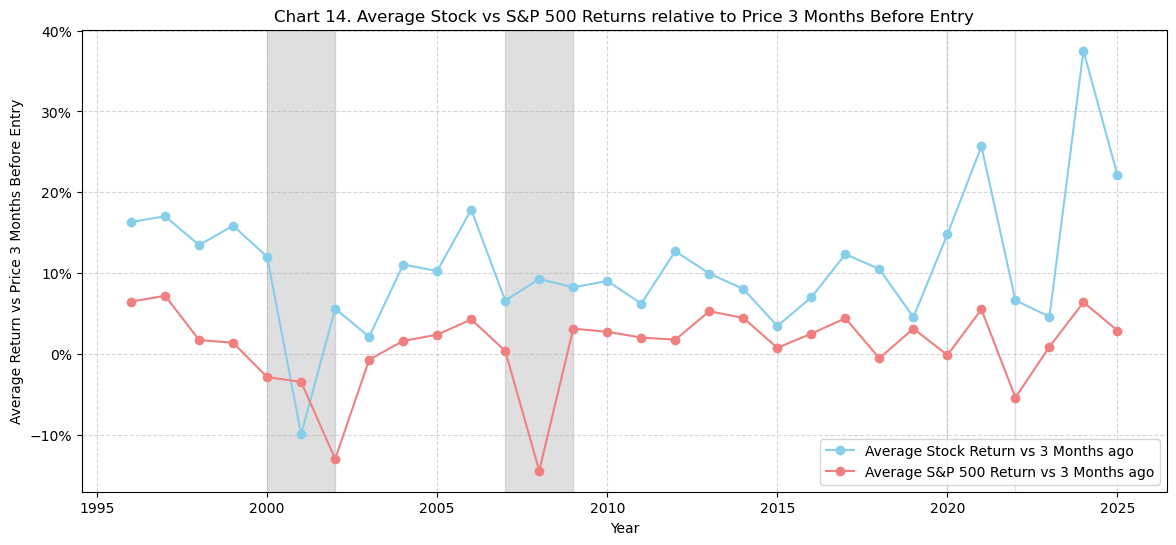

In [87]:
plt.figure(figsize=(14,6))

plt.plot(
    summary_minus_60_returns["year"], 
    summary_minus_60_returns["avg_stock_return_vs_minus_60"], 
    marker='o', 
    label='Average Stock Return vs 3 Months ago', 
    color='skyblue'
)

plt.plot(
    summary_minus_60_returns["year"], 
    summary_minus_60_returns["avg_sp500_return_vs_minus_60"], 
    marker='o', 
    label='Average S&P 500 Return vs 3 Months ago', 
    color='lightcoral'
)

for i, (start, end) in enumerate(bear_periods):
    start_year = pd.to_datetime(start).year
    end_year = pd.to_datetime(end).year
    plt.axvspan(
        start_year, 
        end_year, 
        color='grey', 
        alpha=0.25,
    )

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xlabel("Year")
plt.ylabel("Average Return vs Price 3 Months Before Entry")
plt.title("Chart 14. Average Stock vs S&P 500 Returns relative to Price 3 Months Before Entry")

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()